In [1]:
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mne_bids import BIDSPath
from scipy.ndimage import gaussian_filter1d
from tqdm.auto import tqdm
import mne



In [2]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

import mne
mne.viz.set_3d_backend('notebook')



Using notebook 3d backend.


# Fig 3: Decoding and reaction-time prediction

Publication notebook with two parts:

- **A. Time-resolved multivariate decoding** — ROI-level high-gamma decoding accuracy across
  trial phases (Stimulus → Delay → Go → Response). Data:
  `../results/{task}(roi)(bipolar)/` resolved H5 outputs.
- **B. Reaction-time prediction** — electrode-wise sliding-window Ridge prediction of RT
  (Pearson \(r\)) from high-gamma. Data:
  `../results/{task}(bipolar)(hammers)/RT/`. Tasks:
  LexicalDelay, PhonemeSequence, PictureNaming.

File exports (`savefig` / batch write) are commented out until panels are finalized.


## A. Time-resolved multivariate decoding


## Config

Edit `hue_order`, `hemi`, `description`, and `articulator_phoneme_filter` at the top of
the next cell. `FIGURE_SPECS` lists all task × decode-type combinations for batch export.
Each entry is `(task, decode_type)` or `(task, decode_type, description)`; omit the third
element to use the global `description` (default `Repeat`).

In [3]:
ref = 'bipolar'
phases = ['Stimulus', 'Delay', 'Go', 'Response']

# --- user-editable ROI / cohort filters ---
hue_order = ['AIC', 'PIC', 'SMC','STG']  # e.g. add 'STG'
hemi = 'Left'
description = 'Repeat'
articulator_phoneme_filter = '1'  # path.recording for articulator H5s; None = all phonemes

smooth_sigma = 2
results_root = Path('..') / 'results'
export_dir = Path('../img/fig3')

# All publication panels to generate.
# Each entry: (task, decode_type) or (task, decode_type, description).
FIGURE_SPECS = [
    ('LexicalDelay', 'lexicality'),
    ('LexicalDelay', 'lexicality', 'Decision'),
    ('LexicalDelay', 'phoneme'),
    ('LexicalDelay', 'articulator'),
    ('PhonemeSequence', 'phoneme'),
    ('PhonemeSequence', 'articulator'),
]


def parse_figure_spec(spec: tuple) -> tuple[str, str, str]:
    """Return (task, decode_type, description) from a FIGURE_SPECS entry."""
    if len(spec) == 2:
        task, decode_type = spec
        return task, decode_type, description
    if len(spec) == 3:
        task, decode_type, spec_description = spec
        return task, decode_type, spec_description
    raise ValueError(f'Invalid FIGURE_SPECS entry: {spec!r}')


def figure_output_name(task: str, decode_type: str, spec_description: str) -> str:
    """SVG basename; non-Repeat conditions get a suffix (e.g. _Decision)."""
    base = f'fig3_{task}_{decode_type}'
    if spec_description != 'Repeat':
        return f'{base}_{spec_description}.svg'
    return f'{base}.svg'

ROI_COLOR_MAP = {
    'AIC': red,
    'PIC': blue,
    'STG': stg_color,
    'SMC': 'black',
}


def roi_colors_for(rois: list[str]) -> list[str]:
    return [ROI_COLOR_MAP.get(roi, 'gray') for roi in rois]

## Load resolved decoding results

`load_resolved_decoding()` reads all matching H5 files and returns a long-format
DataFrame. Supports lexicality, phoneme, and articulator decode types. For articulator,
`path.recording` is stored in the `phoneme` column and filtered via
`articulator_phoneme_filter` (default `'1'`). Missing result directories or empty
matches return an empty DataFrame instead of raising.

`chance_level(decode_type, task)` returns `1 / n_classes` from pipeline defaults.

In [4]:
# Default n_classes from decoding pipeline / legacy fig3 notebooks.
# Keys are (decode_type, task); articulator assumes articulator_phoneme_filter='1'.
N_CLASSES = {
    ('phoneme', 'LexicalDelay'): 5,
    ('phoneme', 'PhonemeSequence'): 5,
    ('articulator', 'LexicalDelay'): 4,
    ('articulator', 'PhonemeSequence'): 4,
    ('lexicality', 'LexicalDelay'): 2,
}
_DECODE_TYPE_DEFAULT_N = {
    'phoneme': 5,
    'articulator': 4,
    'lexicality': 2,
}


def chance_level(decode_type: str, task: str) -> float:
    """Chance accuracy = 1 / n_classes for the decode type and task."""
    n = N_CLASSES.get((decode_type, task))
    if n is None:
        n = _DECODE_TYPE_DEFAULT_N.get(decode_type)
    if n is None:
        warnings.warn(f'Unknown decode_type={decode_type!r}; using n_classes=2')
        n = 2
    return 1.0 / n


def phase_accuracy_bar_params(decode_type: str, task: str) -> tuple[float, float]:
    """Significance-bar strip pad and bar height from legacy fig3 notebooks."""
    n = N_CLASSES.get((decode_type, task))
    if n is None:
        n = _DECODE_TYPE_DEFAULT_N.get(decode_type, 2)
    if decode_type == 'lexicality':
        return 0.01, 0.02
    if n >= 5:
        return 0.03, 0.02
    return 0.03, 0.01


def phase_accuracy_data_ylim(
    scores: pd.DataFrame,
    *,
    phases: list[str],
    hue_order: list[str],
    hemi: str,
    ymin_pad: float = 0.1,
    ymax_pad: float = 0.1,
) -> tuple[float, float]:
    """Data-driven ymin/ymax from accuracy values actually plotted."""
    subset = scores[
        scores['hemi'].eq(hemi)
        & scores['phase'].isin(phases)
        & scores['roi'].isin(hue_order)
    ]
    acc = subset['accuracy'].dropna()
    if acc.empty:
        raise ValueError('No accuracy values for y-axis limits.')
    ymin = max(0.0, float(acc.min()) - ymin_pad)
    ymax = float(acc.max()) + ymax_pad
    return ymin, ymax


SCORE_COLUMNS = [
    'time', 'fold', 'accuracy', 'baseline', 'p_value', 'mask',
    'roi', 'phase', 'hemi', 'description', 'phoneme', 'datatype', 'band',
]


def _empty_scores() -> pd.DataFrame:
    return pd.DataFrame(columns=SCORE_COLUMNS)


def _h5_to_long_df(path, smooth_sigma: float = 2) -> pd.DataFrame:
    with h5py.File(path, 'r') as mat:
        accuracy = mat['accuracy'][()]
        time = mat['time'][()]
        p_value = mat['p_values'][()]
        baseline = mat['baseline'][()]
        mask = mat['mask'][()] if 'mask' in mat else None

    n_time, n_fold = accuracy.shape
    baseline_mean = baseline.mean(axis=-1)

    accuracy = gaussian_filter1d(
        accuracy, sigma=smooth_sigma, axis=0, mode='nearest',
    )

    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    df_acc = df_acc.melt(id_vars='time', var_name='fold', value_name='accuracy')
    df_base = df_base.melt(id_vars='time', var_name='fold', value_name='baseline')
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    if mask is not None:
        df_p['mask'] = mask.astype(bool)
    df = df.merge(df_p, on='time', how='left')

    hemi_label = 'Left' if path.subject.endswith('l') else 'Right'
    df['roi'] = path.subject[:-1]
    df['phase'] = path.processing
    df['hemi'] = hemi_label
    df['description'] = path.description
    df['phoneme'] = path.recording
    df['datatype'] = path.datatype
    df['band'] = path.suffix
    return df


def load_resolved_decoding(
    task: str,
    decode_type: str,
    *,
    ref: str = 'bipolar',
    rois=None,
    hemi: str | None = None,
    description: str | None = None,
    articulator_phoneme_filter: str | None = '1',
    smooth_sigma: float = 2,
    results_root=Path('..') / 'results',
) -> pd.DataFrame:
    """Load time-resolved decoding scores from resolved H5 outputs.

  Supports lexicality, phoneme, and articulator decode types. For articulator,
  ``path.recording`` is stored in the ``phoneme`` column (legacy pattern).

  Returns an empty DataFrame when the results directory is missing, no H5 files
  match, or every file is unreadable.
    """
    results_root = Path(results_root)
    root = results_root / f'{task}(roi)({ref})'
    if not root.exists():
        warnings.warn(f'Missing decoding results directory: {root}')
        return _empty_scores()

    result_path = BIDSPath(
        datatype=f'(decode)(resolved){decode_type}',
        root=str(root),
        suffix='highgamma',
        check=False,
    )
    paths = result_path.match()
    if not paths:
        warnings.warn(
            f'No resolved decoding H5 files for task={task}, decode_type={decode_type}'
        )
        return _empty_scores()

    frames = []
    for path in paths:
        try:
            frames.append(_h5_to_long_df(path, smooth_sigma=smooth_sigma))
        except OSError as exc:
            warnings.warn(f'Skipping unreadable file {path}: {exc}')

    if not frames:
        return _empty_scores()

    scores = pd.concat(frames, ignore_index=True)

    if description is not None:
        scores = scores[scores['description'] == description]

    if hemi is not None:
        scores = scores[scores['hemi'] == hemi]

    if rois is not None:
        scores = scores[scores['roi'].isin(rois)]

    if decode_type == 'articulator' and articulator_phoneme_filter is not None:
        scores = scores[scores['phoneme'] == articulator_phoneme_filter]

    return scores.reset_index(drop=True)

In [5]:
# Quick preview for one combination (edit task/decode_type as needed)
preview_task, preview_decode, preview_description = parse_figure_spec(FIGURE_SPECS[0])

scores = load_resolved_decoding(
    preview_task,
    preview_decode,
    ref=ref,
    rois=hue_order,
    hemi=hemi,
    description=preview_description,
    articulator_phoneme_filter=articulator_phoneme_filter,
    smooth_sigma=smooth_sigma,
    results_root=results_root,
)
print(
    f'Preview {preview_task}/{preview_decode}: {len(scores):,} rows | '
    f'ROIs: {sorted(scores.roi.unique()) if not scores.empty else []} | '
    f'chance={chance_level(preview_decode, preview_task):.3f}'
)
scores.head()

Preview LexicalDelay/lexicality: 4,640 rows | ROIs: ['AIC', 'PIC', 'SMC', 'STG'] | chance=0.500


,time,fold,accuracy,baseline,p_value,mask,roi,phase,hemi,description,phoneme,datatype,band
0,-0.20,0,0.593697,0.492941,0.452736,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
1,-0.17,0,0.547599,0.486471,0.985075,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
2,-0.14,0,0.515282,0.497647,0.935323,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
3,-0.11,0,0.502752,0.490147,0.497512,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
4,-0.08,0,0.505556,0.494412,0.109453,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma


## Four-phase accuracy line plot

One row of panels (Stimulus → Response) with ROI-colored accuracy traces. Significance
bars above each trace mark cluster-corrected `p < 0.01` time points (`fold == 1`, legacy).

In [6]:
from matplotlib.ticker import MaxNLocator


def plot_phase_accuracy(
    scores: pd.DataFrame,
    *,
    phases: list[str],
    hue_order: list[str],
    hemi: str = 'Left',
    chance: float | None = None,
    decode_type: str | None = None,
    task: str | None = None,
    roi_colors=None,
    xlim: tuple[float, float] = (-0.5, 1.5),
    ymax: float | None = None,
    ymin: float | None = None,
    pad: float | None = None,
    bar_h: float | None = None,
    sig_p: float = 0.01,
    sig_fold: int = 1,
    legend_panel: int | None = None,
    xlabel_panel: int | None = None,
):
    """Four-phase decoding accuracy figure (publication style, legacy fig3)."""
    if scores.empty:
        raise ValueError('No decoding scores to plot. Check results paths and parameters.')

    if chance is None:
        if decode_type is None or task is None:
            raise ValueError('Provide chance or both decode_type and task.')
        chance = chance_level(decode_type, task)
    if ymin is None or ymax is None:
        data_ymin, data_ymax = phase_accuracy_data_ylim(
            scores, phases=phases, hue_order=hue_order, hemi=hemi,
        )
        ymin = data_ymin if ymin is None else ymin
        ymax = data_ymax if ymax is None else ymax
    if pad is None or bar_h is None:
        if decode_type is None or task is None:
            raise ValueError('Provide pad/bar_h or both decode_type and task.')
        default_pad, default_bar_h = phase_accuracy_bar_params(decode_type, task)
        pad = default_pad if pad is None else pad
        bar_h = default_bar_h if bar_h is None else bar_h

    roi_colors = roi_colors or roi_colors_for(hue_order)
    n_phases = len(phases)
    legend_panel = n_phases // 2 if legend_panel is None else legend_panel
    xlabel_panel = n_phases // 2 if xlabel_panel is None else xlabel_panel
    y_top = ymax + pad + len(hue_order) * (bar_h + 0.005) + 0.02

    fig, axes = plt.subplots(1, n_phases, figsize=(2.5 * n_phases * cm, 3 * cm))
    if n_phases == 1:
        axes = [axes]

    plt.subplots_adjust(wspace=-0.1)

    for j, phase in enumerate(phases):
        ax = axes[j]
        subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]

        sns.lineplot(
            data=subset,
            x='time', y='accuracy', hue='roi',
            palette=roi_colors, hue_order=hue_order,
            lw=1, ax=ax, legend=(j == legend_panel),
        )
        ax.set_autoscale_on(False)
        ax.margins(y=0)

        for k, roi in enumerate(hue_order):
            roi_data = subset[(subset.roi == roi) & (subset.fold == sig_fold)].sort_values('time')
            if roi_data.empty:
                continue
            if 'mask' in roi_data.columns and roi_data['mask'].notna().any():
                mask = roi_data['mask'].values.astype(bool)
            else:
                mask = roi_data['p_value'].values < sig_p
            offset = k * (bar_h + 0.005)
            if mask.any():
                ax.fill_between(
                    roi_data['time'].values,
                    ymax + pad + offset,
                    ymax + pad + bar_h + offset,
                    where=mask,
                    color=roi_colors[k],
                    alpha=1,
                    step='mid',
                    linewidth=0,
                )

    for j, phase in enumerate(phases):
        ax = axes[j]
        ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
        ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
        ax.set_xlim(*xlim)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(phase.capitalize(), fontsize=fontsize)

        if j == 0:
            ax.set_ylabel('Accuracy', fontsize=fontsize)

    axes[xlabel_panel].set_xlabel('Time (s)', fontsize=fontsize)
    if axes[legend_panel].get_legend() is not None:
        axes[legend_panel].legend(fontsize=fontsize)

    for ax in axes:
        sns.despine(ax=ax, trim=True, offset=0.1)

    for ax in axes[1:]:
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_ylabel('')

    axes[0].yaxis.set_tick_params(labelleft=True)
    axes[0].yaxis.set_visible(True)

    for ax in axes:
        ax.set_ylim(ymin, y_top)
        ax.set_ybound(ymin, y_top)

    axes[0].yaxis.set_major_locator(MaxNLocator(nbins=3))

    return fig, axes

Preview ylim expected=(0.032, 1.067) got=(0.032, 1.067) ticks=[0.  0.4 0.8 1.2]


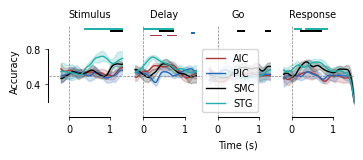

In [7]:
# Preview plot for the first FIGURE_SPECS entry
if scores.empty:
    print('Skipping preview plot: no decoding data loaded.')
else:
    preview_ymin, preview_ymax = phase_accuracy_data_ylim(
        scores, phases=phases, hue_order=hue_order, hemi=hemi,
    )
    preview_pad, preview_bar_h = phase_accuracy_bar_params(preview_decode, preview_task)
    preview_y_top = (
        preview_ymax + preview_pad
        + len(hue_order) * (preview_bar_h + 0.005) + 0.02
    )
    fig, axes = plot_phase_accuracy(
        scores,
        phases=phases,
        hue_order=hue_order,
        hemi=hemi,
        decode_type=preview_decode,
        task=preview_task,
        roi_colors=roi_colors_for(hue_order),
        ymin=preview_ymin,
        ymax=preview_ymax,
    )
    got = axes[0].get_ylim()
    print(
        f'Preview ylim expected=({preview_ymin:.3f}, {preview_y_top:.3f}) '
        f'got=({got[0]:.3f}, {got[1]:.3f}) ticks={axes[0].get_yticks().round(3)}'
    )
    plt.show()

## Batch export (decoding)

Run on a compute node when ready. Writes `../img/fig3/fig3_{task}_{decode_type}.svg`
(Repeat) or `fig3_{task}_{decode_type}_{description}.svg` (other conditions) for every
entry in `FIGURE_SPECS`.

**Output currently commented out** — uncomment `fig.savefig(...)` below to write files.


Would save ../img/fig3/fig3_LexicalDelay_lexicality.svg (chance=0.500, ylim=(0.03, 1.07), n=4,640)
Would save ../img/fig3/fig3_LexicalDelay_lexicality_Decision.svg (chance=0.500, ylim=(0.04, 1.10), n=4,640)
Would save ../img/fig3/fig3_LexicalDelay_phoneme.svg (chance=0.200, ylim=(0.00, 0.63), n=4,350)
Skip fig3_LexicalDelay_articulator.svg: no decoding data loaded.
Would save ../img/fig3/fig3_PhonemeSequence_phoneme.svg (chance=0.200, ylim=(0.00, 0.65), n=3,770)
Would save ../img/fig3/fig3_PhonemeSequence_articulator.svg (chance=0.250, ylim=(0.00, 0.94), n=4,640)
Decoding batch export is commented out.


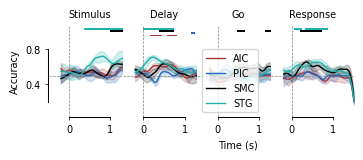

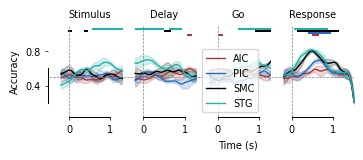

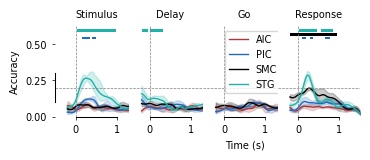

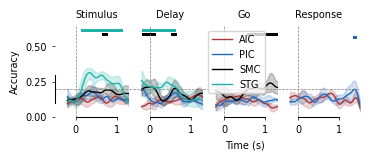

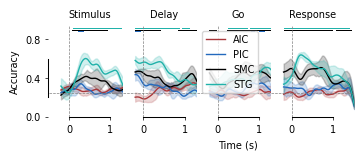

In [8]:
export_dir.mkdir(parents=True, exist_ok=True)

for spec in FIGURE_SPECS:
    task, decode_type, spec_description = parse_figure_spec(spec)
    scores = load_resolved_decoding(
        task,
        decode_type,
        ref=ref,
        rois=hue_order,
        hemi=hemi,
        description=spec_description,
        articulator_phoneme_filter=articulator_phoneme_filter,
        smooth_sigma=smooth_sigma,
        results_root=results_root,
    )
    out_path = export_dir / figure_output_name(task, decode_type, spec_description)

    if scores.empty:
        print(f'Skip {out_path.name}: no decoding data loaded.')
        continue

    chance = chance_level(decode_type, task)
    ymin, ymax = phase_accuracy_data_ylim(
        scores, phases=phases, hue_order=hue_order, hemi=hemi,
    )
    pad, bar_h = phase_accuracy_bar_params(decode_type, task)
    y_top = ymax + pad + len(hue_order) * (bar_h + 0.005) + 0.02
    fig, _ = plot_phase_accuracy(
        scores,
        phases=phases,
        hue_order=hue_order,
        hemi=hemi,
        decode_type=decode_type,
        task=task,
        roi_colors=roi_colors_for(hue_order),
        ymin=ymin,
        ymax=ymax,
    )
    # fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(
        f'Would save {out_path} '
        f'(chance={chance:.3f}, ylim=({ymin:.2f}, {y_top:.2f}), n={len(scores):,})'
    )

print('Decoding batch export is commented out.')

## B. Reaction-time prediction

Sliding-window Ridge regression predicting RT from channel HGA (Pearson \(r\)), with
permutation + cluster correction (`mask`). Coordinates / ROI labels come from packaged
HGA `*_coord.csv` under hammers packaging.

Significant-channel windows (legacy):

- Delay: time ∈ [0, 0.8], `mask`
- Go / Response: time ∈ [-0.5, 1], `mask`

Condition filter: `description == 'Repeat'`.


### RT config


In [ ]:
rt_ref = 'bipolar'
rt_atlas = 'hammers'
rt_tasks = ['LexicalDelay', 'PhonemeSequence']
rt_description = 'Repeat'
rt_band_suffix = 'highgamma'

# Phase windows used to declare a channel "RT-significant"
RT_SIG_WINDOWS = {
    'Delay': (0.0, 0.8),
    'Go': (-0.5, 1.0),
    'Response': (-0.5, 1.0),
}

rt_hue_order = ['AIC', 'PIC', 'SMC','STG']
rt_phases = ['Stimulus', 'Delay', 'Go', 'Response']

# Match fig1 / fig2 exactly (string path, template subject)
recon_dir = '/cwork/ns458/ECoG_Recon/'
FS_SUBJECT = 'cvs_avg35_inMNI152'
rt_export_dir = Path('../img/fig3')

# Drop noisy / non-cortical ROIs from RT spatial summaries (legacy list, hammers names)
RT_EXCLUDE_ROIS = {
    'mOccG', 'OPC', 'Hipp', 'Central', 'Put', 'PhG', 'GRect', 'LinGs', 'CollatAnt',
    'LinG', 'Amyg', 'LatV', 'InfLatV', 'PCun', 'CC_Central(unknown)', 'Cun', 'VDC',
    'BrainStem(unknown)', 'Intersection', 'OFCs', 'iOccGs', 'Calcarine', 'Thal',
    'OccS', 'FuGs', 'Paracentral', 'PCuns', 'SFGs', 'MFGs', 'IFGs', 'CGs',
    'Unknown', 'BrainStem', 'CC', 'Caud', 'GSubcallosal', 'BrainStem–Thal',
}


def rt_results_root(task: str) -> Path:
    return results_root / f'{task}({rt_ref})({rt_atlas})'



### Load electrode coordinates

Hammers `*_coord.csv` from `results/{task}(bipolar)(hammers)/`. Packaged `x,y,z` are
already `cvs_avg35_inMNI152` template coords (`x_t/y_t/z_t`).

**Do not** apply the fsaverage→cvs mean translation from `fig3_rt_legacy` cell 6 —
that shift was for old `results/{task}(bipolar)/` HGA only. On current data,
`new ≈ old + translation`; applying it again shifts electrodes ~26 mm off the brain.



In [ ]:
# Same source as fig1: hammers packaged template xyz (NO fsaverage→cvs translation).
coord_paths = []
for task in rt_tasks:
    coord_paths.extend(
        BIDSPath(
            root=str(rt_results_root(task)),
            datatype='HGA',
            suffix='coord',
            check=False,
        ).match()
    )

if not coord_paths:
    raise FileNotFoundError(
        f'No HGA coord CSVs under results/{{task}}({rt_ref})({rt_atlas})/ '
        f'for tasks={rt_tasks}'
    )

coords = pd.concat(
    [pd.read_csv(p) for p in tqdm(coord_paths, desc='load HGA coord')],
    ignore_index=True,
)
coords = coords.dropna(subset=['x', 'y', 'z']).copy()

# Hammers ROI groupings (fig1 / fig2)
coords.loc[coords['roi'] == 'PrG', 'roi'] = 'SMC'
coords.loc[coords['roi'] == 'PoG', 'roi'] = 'SMC'
coords.loc[coords['roi'] == 'Subcentral', 'roi'] = 'SMC'
coords.loc[coords['roi'] == 'STGp', 'roi'] = 'STG'
coords.loc[coords['roi'] == 'STGa', 'roi'] = 'STG'
coords.loc[coords['roi'] == 'HG', 'roi'] = 'STG'

elec_coords = (
    coords[['channel', 'roi', 'label', 'hemi', 'x', 'y', 'z']]
    .drop_duplicates(subset=['channel'])
    .reset_index(drop=True)
)

print(
    f'Unique electrodes: {len(elec_coords)} | '
    f'ROIs sample: {elec_coords["roi"].value_counts().head(8).to_dict()}'
)
elec_coords.head()



### Load RT H5 results

Long-format table with `score` (Pearson \(r\); column kept as `r2` for legacy plotting
compatibility), `mask`, `pval`, `cluster_pval`, and metadata from the BIDSPath.


In [ ]:
RT_COLUMNS = [
    'channel', 'time', 'r2', 'perm_r2_mean', 'pval', 'cluster_pval', 'mask',
    'subject', 'phase', 'description', 'band', 'task',
]


def _empty_rt() -> pd.DataFrame:
    return pd.DataFrame(columns=RT_COLUMNS)


def _rt_h5_to_long_df(path, task: str) -> pd.DataFrame:
    with h5py.File(path, 'r') as mat:
        score = mat['score'][()]
        time = mat['time'][()]
        channels = [
            ch.decode('utf-8') if isinstance(ch, (bytes, np.bytes_)) else str(ch)
            for ch in mat['channels'][:]
        ]
        pval = mat['pval'][()]
        cluster_pval = mat['cluster_pval'][()]
        mask = mat['mask'][()]
        if 'perm_r2' in mat:
            perm = mat['perm_r2'][()]
        elif 'perm_score' in mat:
            perm = mat['perm_score'][()]
        else:
            perm = None

    perm_mean = perm.mean(axis=-1) if perm is not None else np.full_like(score, np.nan)

    def _wide_to_long(values, name):
        df = pd.DataFrame(values, index=channels, columns=time).reset_index()
        df = df.rename(columns={'index': 'channel'})
        return df.melt(id_vars='channel', var_name='time', value_name=name)

    df = _wide_to_long(score, 'r2')
    df = df.merge(_wide_to_long(perm_mean, 'perm_r2_mean'), on=['channel', 'time'], how='left')
    df = df.merge(_wide_to_long(pval, 'pval'), on=['channel', 'time'], how='left')
    df = df.merge(_wide_to_long(cluster_pval, 'cluster_pval'), on=['channel', 'time'], how='left')
    df = df.merge(_wide_to_long(mask, 'mask'), on=['channel', 'time'], how='left')
    df['mask'] = df['mask'].astype(bool)

    df['subject'] = path.subject
    df['phase'] = path.processing
    df['description'] = path.description
    df['band'] = path.suffix
    df['task'] = task
    return df


def load_reaction_time(
    tasks,
    *,
    ref: str = 'bipolar',
    atlas: str = 'hammers',
    description: str | None = 'Repeat',
    results_root=Path('..') / 'results',
) -> pd.DataFrame:
    """Load RT prediction H5s for one or more tasks into a long DataFrame."""
    frames = []
    results_root = Path(results_root)
    for task in tasks:
        root = results_root / f'{task}({ref})({atlas})'
        if not root.exists():
            warnings.warn(f'Missing RT results directory: {root}')
            continue
        paths = BIDSPath(
            datatype='RT',
            root=str(root),
            suffix='highgamma',
            check=False,
        ).match()
        if not paths:
            warnings.warn(f'No RT H5 files for task={task}')
            continue
        for path in tqdm(paths, desc=f'RT {task}'):
            try:
                frames.append(_rt_h5_to_long_df(path, task))
            except OSError as exc:
                warnings.warn(f'Skipping unreadable RT file {path}: {exc}')

    if not frames:
        return _empty_rt()

    rt = pd.concat(frames, ignore_index=True)
    if description is not None:
        rt = rt[rt['description'] == description]
    return rt.reset_index(drop=True)


rt = load_reaction_time(
    rt_tasks,
    ref=rt_ref,
    atlas=rt_atlas,
    description=rt_description,
    results_root=results_root,
)
print(f'RT rows: {len(rt):,}')
if not rt.empty:
    print('Subjects per task:')
    print(rt.groupby('task')['subject'].nunique())
rt.head()


### Significant RT channel subset

Keep channels present in hammers HGA coords, drop excluded ROIs, and require cluster
significance in at least one of the Delay / Go / Response windows above.


In [ ]:
if rt.empty:
    rt_subset = _empty_rt()
    print('No RT data loaded; rt_subset is empty.')
else:
    rt_ = rt[rt['channel'].isin(elec_coords['channel'])].merge(
        elec_coords, on='channel', how='left',
    )
    rt_ = rt_[~rt_['roi'].isin(RT_EXCLUDE_ROIS)].copy()

    sig_sets = []
    for phase, (t0, t1) in RT_SIG_WINDOWS.items():
        phase_mask = (
            (rt_['phase'] == phase)
            & (rt_['time'] >= t0)
            & (rt_['time'] <= t1)
            & (rt_['mask'])
        )
        sig_sets.append(set(rt_.loc[phase_mask, 'channel'].unique()))

    sig_channels = set().union(*sig_sets)
    rt_subset = rt_[rt_['channel'].isin(sig_channels)].copy()

    print(
        f'RT channels after coord merge: {rt_["channel"].nunique()} | '
        f'significant: {len(sig_channels)} | '
        f'rt_subset rows: {len(rt_subset):,}'
    )
    print('Significant channels per task:')
    print(
        rt_subset.groupby('task')['channel']
        .nunique()
        .rename('n_sig_channels')
    )

rt_subset.head()


### ROI electrode counts

Bar + rose charts for Delay-phase significant electrodes (mean \(r\) per channel for
filtering, legacy).


In [ ]:
def rt_delay_channel_table(rt_subset: pd.DataFrame) -> pd.DataFrame:
    """Per-channel table for Delay-phase significant RT electrodes."""
    rt_phase = rt_subset[rt_subset['phase'] == 'Delay']
    sig_channels = rt_phase.loc[rt_phase['mask'], 'channel'].unique()
    subset = rt_phase[rt_phase['channel'].isin(sig_channels)].copy()
    if subset.empty:
        return subset

    g = subset.groupby('channel')['r2']
    picks = g.min().ge(-1) & g.max().le(1) & g.max().gt(0)
    picks = picks[picks].index
    subset = subset[subset['channel'].isin(picks)]

    return (
        subset.groupby('channel')
        .agg(
            r2=('r2', 'mean'),
            x=('x', 'first'),
            y=('y', 'first'),
            z=('z', 'first'),
            roi=('roi', 'first'),
            label=('label', 'first'),
            phase=('phase', 'first'),
            hemi=('hemi', 'first'),
            subject=('subject', 'first'),
            task=('task', 'first'),
        )
        .reset_index()
    )


rt_delay_coords = rt_delay_channel_table(rt_subset)
print(f'Delay significant channels (filtered): {len(rt_delay_coords)}')

if rt_delay_coords.empty:
    print('Skipping ROI count plots: no Delay significant channels.')
else:
    roi_counts = (
        rt_delay_coords[['roi', 'channel']]
        .dropna()
        .drop_duplicates()
        .groupby('roi', as_index=False)
        .agg(n_electrodes=('channel', 'nunique'))
        .sort_values('n_electrodes', ascending=False)
    )
    print(roi_counts.head(10))

    fig, ax = plt.subplots(figsize=(15 * cm, 6 * cm))
    sns.barplot(
        data=roi_counts, x='roi', y='n_electrodes',
        order=roi_counts['roi'], color='0.3', ax=ax,
    )
    ax.set_xlabel('ROI', fontdict=fontdict)
    ax.set_ylabel('N electrodes', fontdict=fontdict)
    ax.tick_params(axis='x', rotation=90, labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    sns.despine(ax=ax)
    # fig.savefig(rt_export_dir / 'fig3_rt_roi_counts.svg', dpi=300, bbox_inches='tight')
    plt.show()

    # Rose chart (top-10 + OTHERS)
    top_n = 10
    roi_counts_sorted = roi_counts.sort_values('n_electrodes', ascending=False)
    plot_df = pd.concat(
        [
            roi_counts_sorted.iloc[:top_n].copy(),
            pd.DataFrame({
                'roi': ['OTHERS'],
                'n_electrodes': [roi_counts_sorted.iloc[top_n:]['n_electrodes'].sum()],
            }),
        ],
        ignore_index=True,
    )
    values = plot_df['n_electrodes'].to_numpy()
    labels = plot_df['roi'].to_numpy()
    radii = np.sqrt(values)
    n = len(values)
    theta = np.linspace(0.0, 2 * np.pi, n, endpoint=False)
    width = 2 * np.pi / n if n else 2 * np.pi
    rose_colors = [
        red if lab == 'AIC' else blue if lab == 'PIC' else '#C0C0C0' for lab in labels
    ]

    fig, ax = plt.subplots(figsize=(8 * cm, 8 * cm), subplot_kw={'projection': 'polar'})
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.bar(
        theta, radii, width=width, bottom=0.0,
        color=rose_colors, edgecolor='white', linewidth=1, alpha=0.9,
    )
    max_radius = float(radii.max()) if len(radii) else 1.0
    ax.set_ylim(0, max_radius * 1.3)
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    for t, r, v, lab in zip(theta, radii, values, labels):
        ax.text(t, r + max_radius * 0.12, f'{lab}', ha='center', va='center', fontsize=fontsize)
        if r > 0.45:
            ax.text(t, r * 0.75, f'{int(v)}', ha='center', va='center',
                    fontsize=fontsize - 1, color='white')
    ax.set_title(f'Top {top_n} ROIs by electrode count (Delay)', fontsize=fontsize, pad=20)
    # fig.savefig(rt_export_dir / 'fig3_rt_roi_rose_delay.svg', dpi=300, bbox_inches='tight')
    plt.show()


### Brain map (Delay)

Same drawing method as `fig3_rt_legacy.ipynb`: nearest-pial projection on
`cvs_avg35_inMNI152`, then `plotter.add_mesh` spheres. Coordinates must already be
template `x,y,z` (no legacy translation).



In [ ]:
import os

import matplotlib.colors as mcolors
import pyvista as pv
from matplotlib.lines import Line2D
from mne.viz import Brain
from scipy.spatial import cKDTree

# Headless / remote Jupyter (same as fig1 / fig3_rt_legacy)
os.environ.setdefault('PYVISTA_OFF_SCREEN', 'true')
pv.OFF_SCREEN = True
mne.viz.set_3d_backend('notebook')

# Legacy RT brain ROI set
roi_list = ['AIC', 'SMC', 'PIC', 'SFG', 'MFG','MTG', 'IFG', 'IFGs', 'SFGs', 'MFGs','STG','pTL']

if rt_delay_coords.empty:
    print('Skipping brain map: no Delay significant channels.')
else:
    brain_df = rt_delay_coords[rt_delay_coords['roi'].isin(roi_list)].copy()
    brain_df = brain_df.dropna(subset=['x', 'y', 'z'])
    if brain_df.empty:
        print('Skipping brain map: no channels in roi_list.')
    else:
        # --- legacy fig3_rt drawing path ---
        coords = brain_df[['x', 'y', 'z']].to_numpy(dtype=float)
        vals = brain_df['r2'].to_numpy(dtype=float)

        vmin = np.nanpercentile(vals, 2)
        vmax = np.nanpercentile(vals, 99)
        if not np.isfinite(vmin):
            vmin = np.nanmin(vals)
        if not np.isfinite(vmax):
            vmax = np.nanmax(vals)
        if vmin == vmax:
            vmax = vmin + 1e-6

        cmap = blues
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        sizes = 10 + 30 * np.clip((vals - vmin) / (vmax - vmin), 0, 1)

        lh_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial')
        rh_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial')
        lh_tree = cKDTree(lh_coords)
        rh_tree = cKDTree(rh_coords)

        # Sanity: template coords should already sit near cvs pial (no +translation)
        d_all, _ = cKDTree(np.vstack([lh_coords, rh_coords])).query(coords)
        print(
            f'Electrode→pial distance (mm): mean={d_all.mean():.2f}, '
            f'median={np.median(d_all):.2f}, p95={np.percentile(d_all, 95):.2f}'
        )
        if d_all.mean() > 15:
            raise RuntimeError(
                'Coords are far from cvs pial. You likely still applied the legacy '
                'fsaverage→cvs translation — re-run Load electrode coordinates only.'
            )

        lh = Brain(
            'cvs_avg35_inMNI152', subjects_dir=recon_dir, hemi='lh', surf='pial',
            background='white', show=False, cortex=(0.9, 0.9, 0.9), alpha=0.5,
            size=(600 * cm, 600 * cm),
        )
        rh = Brain(
            'cvs_avg35_inMNI152', subjects_dir=recon_dir, hemi='rh', surf='pial',
            background='white', show=False, cortex=(0.9, 0.9, 0.9), alpha=0.5,
            size=(600 * cm, 600 * cm),
        )

        mask_lh = coords[:, 0] < 0
        mask_rh = coords[:, 0] > 0

        if mask_lh.any():
            _, idx = lh_tree.query(coords[mask_lh])
            proj = lh_coords[idx]
            for pt, v, s in zip(proj, vals[mask_lh], sizes[mask_lh]):
                cl = cmap(norm(v))[:3]
                lh._renderer.plotter.add_mesh(
                    pv.PolyData(pt.reshape(1, 3)),
                    render_points_as_spheres=True,
                    point_size=float(s),
                    color=cl,
                    lighting=False,
                    opacity=0.95,
                )

        if mask_rh.any():
            _, idx = rh_tree.query(coords[mask_rh])
            proj = rh_coords[idx]
            for pt, v, s in zip(proj, vals[mask_rh], sizes[mask_rh]):
                cl = cmap(norm(v))[:3]
                rh._renderer.plotter.add_mesh(
                    pv.PolyData(pt.reshape(1, 3)),
                    render_points_as_spheres=True,
                    point_size=float(s),
                    color=cl,
                    lighting=False,
                    opacity=0.95,
                )

        for b in (lh, rh):
            b.show_view(view='lateral', distance=400)
            b._renderer.plotter.window_size = [1400, 1400]

        fig, (ax1, ax2) = plt.subplots(
            1, 2, figsize=(16 * cm, 8 * cm),
            gridspec_kw={'width_ratios': [1, 1]},
        )
        plt.subplots_adjust(wspace=-0.1)
        ax1.imshow(lh.screenshot(mode='rgb')); ax1.axis('off')
        ax2.imshow(rh.screenshot(mode='rgb')); ax2.axis('off')

        example_r2 = [vmin, (vmin + vmax) / 2, vmax]
        example_sizes = 1 + 35 * np.clip(
            (np.array(example_r2) - vmin) / (vmax - vmin), 0, 1,
        )
        handles = [
            Line2D(
                [0], [0], marker='o', linestyle='None',
                markerfacecolor=cmap(norm(r2_val)),
                markeredgecolor=cmap(norm(r2_val)),
                markersize=size * 0.1,
                label=f'r = {r2_val:.2f}',
            )
            for r2_val, size in zip(example_r2, example_sizes)
        ]
        ax2.legend(
            handles=handles, title='CV r', loc='upper right', frameon=False,
            fontsize=7, title_fontsize=7,
        )
        lh.close(); rh.close()
        # fig.savefig(rt_export_dir / 'fig3_rt_spatial_delay.svg', dpi=300, bbox_inches='tight')
        plt.show()



### Temporal RT prediction curves

Mean Pearson \(r(t)\) for selected ROIs across phases. Significance bars mark timepoints
where ≥10% of channels in the ROI are cluster-significant (`mask`).


In [ ]:
def plot_rt_phase_curves(
    rt_subset: pd.DataFrame,
    *,
    rois: list[str],
    phases: list[str],
    palette=None,
    ymax: float = 0.2,
    pad: float = 0.01,
    bar_h: float = 0.01,
    sig_threshold: float = 0.1,
    title: str | None = None,
):
    """Legacy-style RT prediction lines with ROI significance bars."""
    if rt_subset.empty:
        raise ValueError('rt_subset is empty')

    palette = palette or roi_colors_for(rois)
    palette_map = dict(zip(rois, palette))
    sig = rt_subset[rt_subset['mask']].copy()
    sig_channels = sig['channel'].unique().tolist()
    subset = rt_subset[rt_subset['channel'].isin(sig_channels)].copy()

    fig, axes = plt.subplots(
        nrows=1, ncols=len(phases), figsize=(3 * len(phases) * cm, 4 * cm),
    )
    if len(phases) == 1:
        axes = [axes]
    plt.subplots_adjust(wspace=0)

    for ax, phase in zip(axes, phases):
        phase_df = subset[(subset['phase'] == phase) & (subset['roi'].isin(rois))]
        g = phase_df.groupby('channel')['r2']
        if len(g) == 0:
            ax.set_title(phase, fontsize=fontsize)
            continue
        picks = g.min().ge(-1) & g.max().le(1) & g.max().gt(0)
        picks = picks[picks].index
        plot_df = phase_df[phase_df['channel'].isin(picks)]

        sns.lineplot(
            data=plot_df, x='time', y='r2', hue='roi', hue_order=rois,
            palette=palette, lw=0.5, ax=ax, legend=(ax is axes[0]),
        )
        ax.set_ylabel('Pearson r' if ax is axes[0] else '', fontsize=fontsize)
        ax.set_xlabel(f'{phase} onset (s)', fontsize=fontsize)

        bar_base = ymax + pad
        gap = bar_h * 0.1
        for i, roi in enumerate(rois):
            sig_ratio = (
                subset[(subset['phase'] == phase) & (subset['roi'] == roi)]
                .sort_values('time')
                .groupby('time')['mask']
                .mean()
            )
            aggregated = sig_ratio >= sig_threshold
            if aggregated.any():
                y0 = bar_base + i * (bar_h + gap)
                ax.fill_between(
                    sig_ratio.index.to_numpy(), y0, y0 + bar_h,
                    where=aggregated.to_numpy(), color=palette_map[roi],
                    alpha=0.9, step='mid', linewidth=0,
                )
        ax.set_ylim(0, bar_base + len(rois) * (bar_h + gap) + bar_h)

    for ax in axes:
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=7, width=0.75, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=1, trim=True)
        if ax.get_legend() is not None and ax is not axes[0]:
            ax.get_legend().remove()
        elif ax.get_legend() is not None:
            ax.legend(title='', fontsize=7)
        ax.set_yticklabels([]); ax.set_yticks([])
        ax.spines['left'].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=fontsize)
    return fig, axes


if rt_subset.empty:
    print('Skipping RT curves: rt_subset empty.')
else:
    fig, axes = plot_rt_phase_curves(
        rt_subset,
        rois=rt_hue_order,
        phases=rt_phases,
        palette=roi_colors_for(rt_hue_order),
        title='Predict RT (Repeat; LexicalDelay + PhonemeSequence + PictureNaming)',
    )
    # fig.savefig(rt_export_dir / 'fig3_rt_temporal_roi.svg', dpi=300, bbox_inches='tight')
    plt.show()


### Optional: per-task curve panels

Uncomment / run to plot each task separately (same ROIs / phases). File export remains
commented.


In [ ]:
for task_name in rt_tasks:
    sub = rt_subset[rt_subset['task'] == task_name]
    if sub.empty:
        print(f'Skip curves for {task_name}: empty subset')
        continue
    fig, _ = plot_rt_phase_curves(
        sub,
        rois=rt_hue_order,
        phases=rt_phases,
        palette=roi_colors_for(rt_hue_order),
        title=f'Predict RT — {task_name} (Repeat)',
    ) 
    # fig.savefig(
    #     rt_export_dir / f'fig3_rt_temporal_roi_{task_name}.svg',
    #     dpi=300, bbox_inches='tight',
    # )
    plt.show()

print('Per-task RT curve loop is commented out.')
